In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pickle as pkl    
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
from matplotlib.patches import Rectangle


Carico il file dei risultati con i dati dei partecipanti testati fino a dicembre

In [2]:
import pickle as pkl
import pandas as pd

# Carico il file dei risultati con i dati dei partecipanti testati fino a dicembre

with open('results_12_2025.pkl', 'rb') as f:
    df1 = pkl.load(f)

# Elimino Nisnig che non ha capito la regola
df1 = df1[df1['nickname'] != 'Nisnig']

# DANMIL è un outlier nei plot
df1 = df1[df1['nickname'] != 'Danmil']

print("Partecipanti testati fino a dicembre:")
print(sorted(df1['nickname'].dropna().unique()))


Partecipanti testati fino a dicembre:
['Alifoe', 'Annnag', 'Annsch', 'Ashpas', 'Carcri', 'Danray', 'Felmue', 'Finkul', 'Gabtan', 'Giafer', 'Haasaa', 'Hamfra', 'Hilama', 'Ilydar', 'Imameh', 'Joahar', 'Julmei', 'Jussch', 'Katmry', 'Kattar', 'Lalnov', 'Liafie', 'Linpaa', 'Lyvo', 'Marlan', 'Maruch', 'Marwan', 'Merham', 'Naqfai', 'Natres', 'Neltre', 'Nicros', 'Niesam', 'Nikgos', 'Osibar', 'Parkhr', 'Paubec', 'Pujliu', 'Sakmur', 'Shokha', 'Sidnas', 'Simweg', 'Sungha', 'Syezai', 'Talahm', 'Tienng', 'Truhoa', 'Vanren']


Carico il file dei risultati con i dati dei partecipanti testati a luglio

In [3]:
import pandas as pd

with open('results_07_2026.pkl', 'rb') as f:
    df2 = pkl.load(f)


# Elimino Liskal è un outlier nei plot
df2 = df2[df2['nickname'] != 'Liskal']


print("Nuovi partecipanti:")
print(sorted(df2['nickname'].dropna().unique()))

Nuovi partecipanti:
['Amibou', 'Amishe', 'Emamok', 'Entver', 'Melbha', 'Mirfer', 'Nigbaw', 'Phidei', 'Pulagg', 'Sabklo', 'Stekuh', 'Timbus']


Unisco i due dataframe, quello con i dati fino a dicembre e quello con i dati di luglio

In [4]:
import pandas as pd

# Unisco tutti i partecipanti di df2 a df1
all_results = pd.concat([df1, df2], ignore_index=True)

# Salvo in Excel
all_results.to_excel("all_results.xlsx", index=False)

print("File salvato: all_results.xlsx")
print(f"Numero totale di righe: {len(all_results)}")
print(f"Nickname unici: {all_results['nickname'].nunique()}")

print("\nPartecipanti presenti in df2:")
print(sorted(df2["nickname"].unique()))

File salvato: all_results.xlsx
Numero totale di righe: 3600
Nickname unici: 60

Partecipanti presenti in df2:
['Amibou', 'Amishe', 'Emamok', 'Entver', 'Melbha', 'Mirfer', 'Nigbaw', 'Phidei', 'Pulagg', 'Sabklo', 'Stekuh', 'Timbus']


Lavoro sui soggetti che hanno l'ICAR score (ovvero tutti quelli di luglio e quelli di dicembre che hanno fatto il test ICAR)

In [5]:
icar = pd.read_excel("AQ&ICAR16_scores.xlsx")

icar = icar[(icar['ICAR'].notna()) & (icar['ICAR'] != 0)]
print(len(icar[icar['ICAR'].notna()]))

52


aggiungo a all_results.xlsx i dati di ICAR presi dal AQ&ICAR16_scores.xlsx e salvo il nuovo excell dei risultati come allresults_AQ_IQ.xlsx

In [6]:
import pandas as pd

# Carica i file
all_results = pd.read_excel("all_results.xlsx")
icar = pd.read_excel("AQ&ICAR16_scores.xlsx")

# Colonna identificativa e colonna da trasferire (ICAR in questo caso ma se volessi aggiungere altre colonne basta aggiungerle alla lista)
id_col = "nickname"
score_cols = ["AQ_score","ICAR"]

# Controlla che le colonne necessarie esistano nel file ICAR
required_icar = {id_col, *score_cols}

missing_icar = required_icar - set(icar.columns)

if missing_icar:
    raise ValueError(
        f"Nel file AQ&ICAR16_scores.xlsx mancano queste colonne: "
        f"{missing_icar}"
    )

# Controlla che nickname esista in all_results
if id_col not in all_results.columns:
    raise ValueError(
        f"Nel file all_results.xlsx manca la colonna '{id_col}'"
    )

# Mantiene una sola riga per partecipante nel file ICAR
icar_scores = (
    icar[[id_col] + score_cols]
    .dropna(subset=[id_col])
    .drop_duplicates(subset=[id_col])
)

# Verifica che ogni nickname nel file ICAR compaia una sola volta
duplicates = icar[icar.duplicated(subset=[id_col], keep=False)]

if not duplicates.empty:
    print(
        "Attenzione: nel file ICAR alcuni nickname compaiono più volte. "
        "È stata mantenuta la prima riga per ciascun partecipante."
    )
    print(sorted(duplicates[id_col].dropna().unique()))

# Merge many-to-one:
# molte righe/trial in all_results, una riga per soggetto in icar_scores
all_results = all_results.merge(
    icar_scores,
    on=id_col,
    how="left",
    suffixes=("", "_from_icar"),
    validate="many_to_one"
)

# Riempie i valori mancanti oppure crea le colonne se non erano presenti
for col in score_cols:
    imported_col = f"{col}_from_icar"

    if imported_col in all_results.columns:
        # La colonna esisteva già in all_results:
        # conserva i valori presenti e riempie solo quelli mancanti
        all_results[col] = all_results[col].fillna(
            all_results[imported_col]
        )
        all_results = all_results.drop(columns=[imported_col])

    # Se la colonna non esisteva in all_results, il merge l'ha già
    # aggiunta direttamente con il nome originale

# Salva il risultato
output_results = "allresults_AQ_IQ.xlsx"
all_results.to_excel(output_results, index=False)

print(f"File salvato: {output_results}")
print(f"Righe totali: {len(all_results)}")
print(f"Partecipanti totali: {all_results[id_col].nunique()}")

# Riepilogo per ciascun punteggio
for col in score_cols:
    participants_with_score = all_results.loc[
        all_results[col].notna(), id_col
    ].nunique()

    participants_without_score = all_results.loc[
        all_results[col].isna(), id_col
    ].nunique()

    print(f"\n{col}:")
    print(f"  Partecipanti con valore: {participants_with_score}")
    print(f"  Partecipanti senza valore: {participants_without_score}")

File salvato: allresults_AQ_IQ.xlsx
Righe totali: 3600
Partecipanti totali: 60

AQ_score:
  Partecipanti con valore: 60
  Partecipanti senza valore: 0

ICAR:
  Partecipanti con valore: 60
  Partecipanti senza valore: 0


Divido i partecipanti in low e high AQ

In [7]:
import pandas as pd
import numpy as np

df = pd.read_excel("allresults_AQ_IQ.xlsx")

# Crea la variabile di gruppo
df["AQ_group"] = np.where(
    df["AQ_score"].isna(),
    np.nan,
    np.where(df["AQ_score"] < 21, "Low AQ", "High AQ")
)

# Controlla il numero di partecipanti in ciascun gruppo
participants = df.groupby("nickname", as_index=False).first()

print(participants["AQ_group"].value_counts())

AQ_group
High AQ    32
Low AQ     28
Name: count, dtype: int64


Partecipanti totali inclusi: 51
Low AQ: 25
High AQ: 26
Nickname unici prima del filtro: 60

Partecipanti con ICAR uguale a 0:
nickname  AQ_score  ICAR
    Lyvo        28     0
  Annnag        26     0
  Liafie        13     0
  Jussch        38     0
  Annsch        11     0
  Gabtan        21     0
  Haasaa        18     0
  Giafer        27     0
  Tienng        25     0


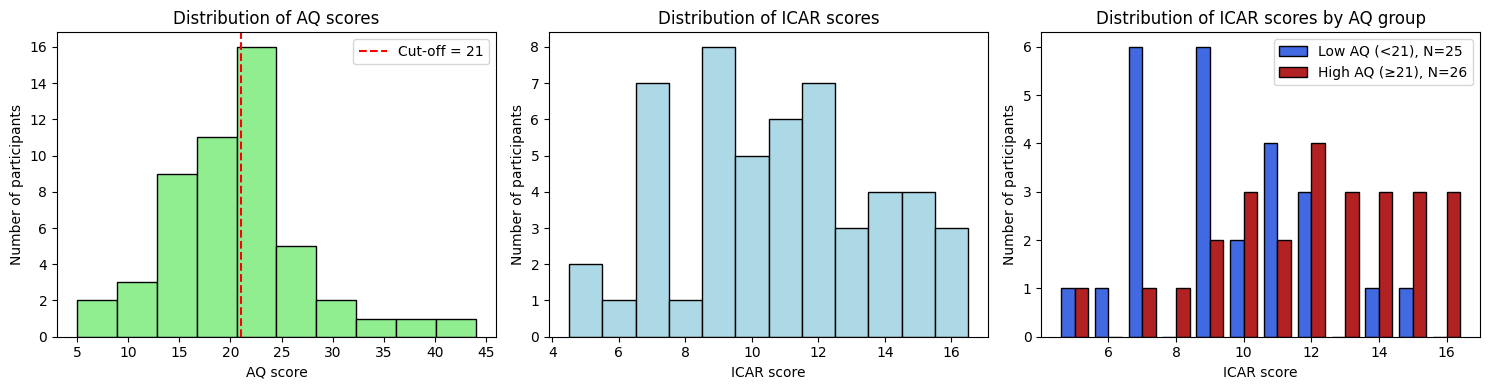

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Una sola riga per partecipante
corr_df = (
    df[["nickname", "AQ_score", "ICAR", "AQ_group"]]
    .drop_duplicates(subset="nickname")
    .copy()
)

# Converte le colonne in numeriche
corr_df["AQ_score"] = pd.to_numeric(
    corr_df["AQ_score"],
    errors="coerce"
)

corr_df["ICAR"] = pd.to_numeric(
    corr_df["ICAR"],
    errors="coerce"
)

# Mantiene solo partecipanti con AQ e ICAR validi
# ed esclude ICAR = 0
corr_df = corr_df[
    corr_df["AQ_score"].notna()
    & corr_df["ICAR"].notna()
    & (corr_df["ICAR"] != 0)
].copy()

# Ricrea il gruppo AQ per sicurezza
corr_df["AQ_group"] = np.where(
    corr_df["AQ_score"] < 21,
    "Low AQ",
    "High AQ"
)

# ICAR diviso per gruppo AQ
low = corr_df.loc[
    corr_df["AQ_group"] == "Low AQ",
    "ICAR"
]

high = corr_df.loc[
    corr_df["AQ_group"] == "High AQ",
    "ICAR"
]

print(f"Partecipanti totali inclusi: {len(corr_df)}")
print(f"Low AQ: {len(low)}")
print(f"High AQ: {len(high)}")



# Una riga per nickname
check_df = (
    df[["nickname", "AQ_score", "ICAR", "AQ_group"]]
    .drop_duplicates(subset="nickname")
    .copy()
)

check_df["AQ_score"] = pd.to_numeric(
    check_df["AQ_score"],
    errors="coerce"
)

check_df["ICAR"] = pd.to_numeric(
    check_df["ICAR"],
    errors="coerce"
)

print("Nickname unici prima del filtro:", check_df["nickname"].nunique())

print("\nPartecipanti con ICAR uguale a 0:")
print(
    check_df.loc[
        check_df["ICAR"] == 0,
        ["nickname", "AQ_score", "ICAR"]
    ].to_string(index=False)
)


# Crea le tre figure
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Figura 1: distribuzione AQ
ax[0].hist(
    corr_df["AQ_score"],
    bins="auto",
    edgecolor="black",
    color="lightgreen"
)

ax[0].axvline(
    21,
    color="red",
    linestyle="--",
    label="Cut-off = 21"
)

ax[0].set_title("Distribution of AQ scores")
ax[0].set_xlabel("AQ score")
ax[0].set_ylabel("Number of participants")
ax[0].legend()

# Figura 2: distribuzione ICAR
ax[1].hist(
    corr_df["ICAR"],
    bins=np.arange(
        corr_df["ICAR"].min() - 0.5,
        corr_df["ICAR"].max() + 1.5,
        1
    ),
    edgecolor="black",
    color="lightblue"
)

ax[1].set_title("Distribution of ICAR scores")
ax[1].set_xlabel("ICAR score")
ax[1].set_ylabel("Number of participants")

# Figura 3: ICAR per gruppo AQ
icar_bins = np.arange(
    corr_df["ICAR"].min() - 0.5,
    corr_df["ICAR"].max() + 1.5,
    1
)

ax[2].hist(
    [low, high],
    bins=icar_bins,
    histtype="bar",
    stacked=False,
    color=["royalblue", "firebrick"],
    edgecolor="black",
    label=[
        f"Low AQ (<21), N={low.shape[0]}",
        f"High AQ (≥21), N={high.shape[0]}"
    ]
)

ax[2].set_title("Distribution of ICAR scores by AQ group")
ax[2].set_xlabel("ICAR score")
ax[2].set_ylabel("Number of participants")
ax[2].legend()

plt.tight_layout()
plt.show()


In [9]:
# print(f"Numero di partecipanti: {corr_df['nickname'].nunique()}")

# print("\nValori AQ e ICAR per partecipante:\n")

# for _, row in corr_df.sort_values("nickname").iterrows():
#     print(
#         f"{row['nickname']}: "
#         f"AQ = {row['AQ_score']}, "
#         f"ICAR = {row['ICAR']}"
#     )

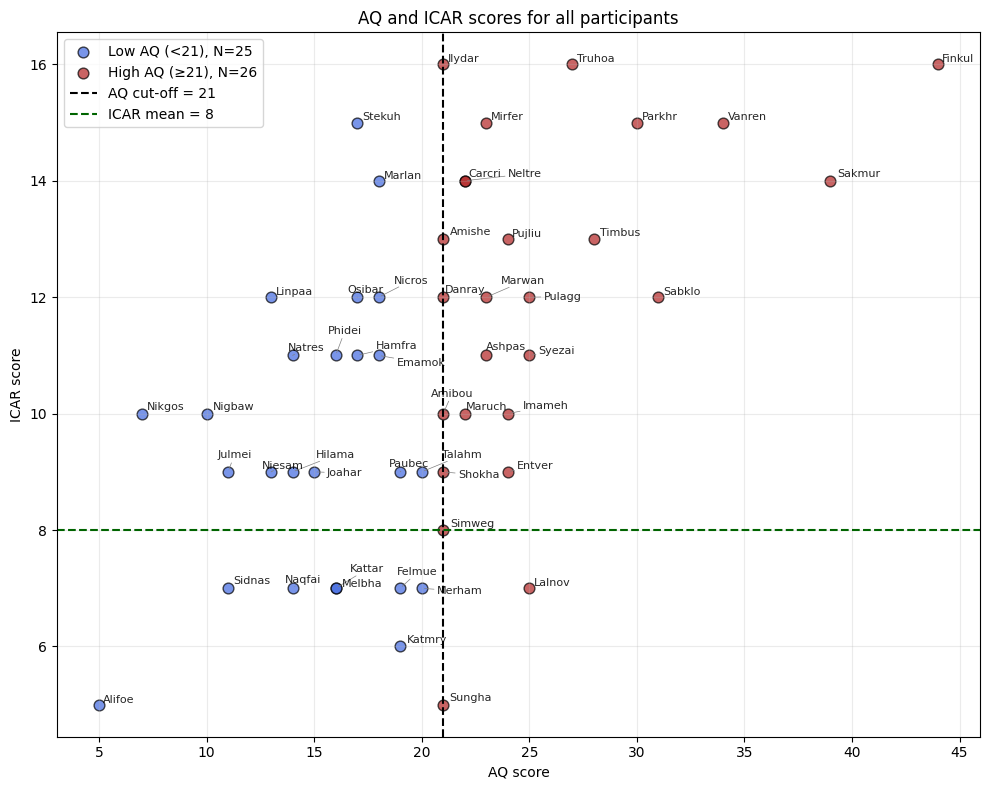

In [10]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

AQ_CUTOFF = 21
ICAR_MEAN = 8

low_mask = corr_df["AQ_group"] == "Low AQ"
high_mask = corr_df["AQ_group"] == "High AQ"

fig, ax = plt.subplots(figsize=(10, 8))

# Low AQ
ax.scatter(
    corr_df.loc[low_mask, "AQ_score"],
    corr_df.loc[low_mask, "ICAR"],
    color="royalblue",
    edgecolor="black",
    alpha=0.7,
    s=60,
    label=f"Low AQ (<21), N={low_mask.sum()}"
)

# High AQ
ax.scatter(
    corr_df.loc[high_mask, "AQ_score"],
    corr_df.loc[high_mask, "ICAR"],
    color="firebrick",
    edgecolor="black",
    alpha=0.7,
    s=60,
    label=f"High AQ (≥21), N={high_mask.sum()}"
)

# Aggiunge i nickname
texts = []

for _, row in corr_df.iterrows():
    texts.append(
        ax.text(
            row["AQ_score"],
            row["ICAR"],
            str(row["nickname"]),
            fontsize=8,
            alpha=0.85
        )
    )

# Sposta automaticamente le etichette per evitare sovrapposizioni
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        linewidth=0.5
    )
)

# AQ cut-off
ax.axvline(
    x=AQ_CUTOFF,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"AQ cut-off = {AQ_CUTOFF}"
)

# ICAR mean
ax.axhline(
    y=ICAR_MEAN,
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
    label=f"ICAR mean = {ICAR_MEAN}"
)

ax.set_xlabel("AQ score")
ax.set_ylabel("ICAR score")
ax.set_title("AQ and ICAR scores for all participants")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

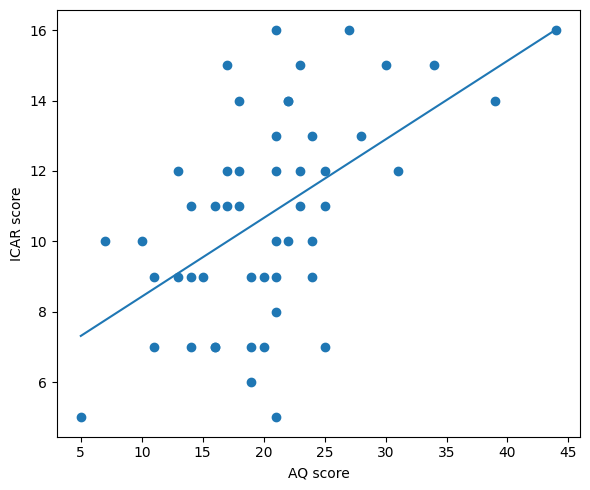

N = 51
Pearson r = 0.540
p = 0.0000


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Correlazione di Pearson
r, p = pearsonr(corr_df["AQ_score"], corr_df["ICAR"])

# Retta di regressione
m, b = np.polyfit(corr_df["AQ_score"], corr_df["ICAR"], 1)
x = np.linspace(corr_df["AQ_score"].min(), corr_df["AQ_score"].max(), 100)

# Grafico
plt.figure(figsize=(6, 5))

plt.scatter(
    corr_df["AQ_score"],
    corr_df["ICAR"]
)

plt.plot(
    x,
    m * x + b
)

plt.xlabel("AQ score")
plt.ylabel("ICAR score")

plt.tight_layout()
plt.show()

print(f"N = {len(corr_df)}")
print(f"Pearson r = {r:.3f}")
print(f"p = {p:.4f}")